# Asian Arithmetic Option Pricing Using Johnson Moment Matching

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial
from itertools import combinations_with_replacement
from collections import Counter

from scipy.optimize import least_squares
from scipy.stats import norm
from numpy.polynomial.hermite import hermgauss

#### GAUSS-HERMITE QUADRATURE

In [2]:
#Gauss-Hermite quadrature computes expectations of functions of a standard normal random variable Z.
GH_ORDER = 80
gh_x, gh_w = hermgauss(GH_ORDER)
Z_NODES = np.sqrt(2) * gh_x
Z_WEIGHTS = gh_w / np.sqrt(np.pi)

#### GBM PRODUCT MOMENTS

In [16]:
def product_moment_gbm(S0, r, q, sigma, times):
    times = np.array(times, dtype=float)
    k = len(times)
    #Drift contribution
    drift_part = (r - q) * np.sum(times)
    #Covariance contribution from Brownian motion
    cov_part = 0.0

    for i in range(k):
        for j in range(i + 1, k):
            cov_part += min(times[i], times[j])

    return (S0 ** k) * np.exp(drift_part + sigma**2 * cov_part)

def ordered_multiplicity(combo):
    counts = Counter(combo)
    m = factorial(len(combo))
    for c in counts.values():
        m //= factorial(c)
    return m

def raw_moment_arithmetic_average(S0, r, q, sigma, T, n_obs, k, start_time=None, end_time=None):
    if start_time is None:
        start_time = T / n_obs

    if end_time is None:
        end_time = T

    times = np.linspace(start_time, end_time, n_obs)

    total = 0.0
    #using combinations with replacement instead of all ordered k-tuples.
    for combo in combinations_with_replacement(range(n_obs), k):
        multiplicity = ordered_multiplicity(combo)
        selected_times = times[list(combo)]
        total += multiplicity * product_moment_gbm(
            S0=S0,
            r=r,
            q=q,
            sigma=sigma,
            times=selected_times)
    return total / (n_obs ** k)

def arithmetic_average_moments(S0, r, q, sigma, T, n_obs, start_time=None, end_time=None):
    m1 = raw_moment_arithmetic_average(S0, r, q, sigma, T, n_obs, 1, start_time, end_time)
    m2 = raw_moment_arithmetic_average(S0, r, q, sigma, T, n_obs, 2, start_time, end_time)
    m3 = raw_moment_arithmetic_average(S0, r, q, sigma, T, n_obs, 3, start_time, end_time)
    m4 = raw_moment_arithmetic_average(S0, r, q, sigma, T, n_obs, 4, start_time, end_time)

    mean = m1
    variance = m2 - m1**2
    sd = np.sqrt(variance)

    third_central = m3 - 3*m1*m2 + 2*m1**3
    fourth_central = m4 - 4*m1*m3 + 6*m1**2*m2 - 3*m1**4

    skewness = third_central / sd**3
    kurtosis = fourth_central / sd**4

    return {
        "raw1": m1,
        "raw2": m2,
        "raw3": m3,
        "raw4": m4,
        "mean": mean,
        "variance": variance,
        "sd": sd,
        "skew": skewness,
        "kurt": kurtosis
    }

#### JOHNSON DISTRIBUTION MOMENT MATCHING

In [17]:
#Applies the Johnson base transformation before location-scale adjustment.
def johnson_base_transform(z, a, b, family):
    y = (z - a) / b
    if family == "SL":
        return np.exp(y)
    if family == "SU":
        return np.sinh(y)
    raise ValueError("family must be either 'SL' or 'SU'")

#Computes mean, sd, skewness, kurtosis of the base Johnson variable.
def johnson_base_stats(a, b, family):
    Y = johnson_base_transform(Z_NODES, a, b, family)
    mean_Y = np.sum(Z_WEIGHTS * Y)
    centered = Y - mean_Y
    var_Y = np.sum(Z_WEIGHTS * centered**2)
    sd_Y = np.sqrt(var_Y)
    skew_Y = np.sum(Z_WEIGHTS * centered**3) / sd_Y**3
    kurt_Y = np.sum(Z_WEIGHTS * centered**4) / sd_Y**4

    return mean_Y, sd_Y, skew_Y, kurt_Y

#Fits Johnson SU and/or SL parameters by matching skewness and kurtosis. Once a and b are found, c and d are chosen to match mean and sd.
def fit_johnson_by_moments(target_mean, target_sd, target_skew, target_kurt, families=("SU", "SL")):
    best = None

    #Multiple starting values improve robustness.
    starting_values = [
        (-2.0, np.log(0.5)),
        (-1.0, np.log(0.8)),
        (0.0,  np.log(1.0)),
        (1.0,  np.log(1.2)),
        (2.0,  np.log(1.5)),
        (0.0,  np.log(2.0)),
        (-1.0, np.log(2.0)),
        (1.0,  np.log(2.0))]

    for family in families:
        for start in starting_values:
            def residual(theta):
                a = theta[0]
                b = np.exp(theta[1])   #forces b > 0

                _, _, skew_fit, kurt_fit = johnson_base_stats(a, b, family)
                #Scale residuals so kurtosis does not dominate too much.
                return np.array([
                    skew_fit - target_skew,
                    (kurt_fit - target_kurt) / 2.0])
            res = least_squares(
                residual,
                x0=np.array(start),
                max_nfev=5000,
                xtol=1e-12,
                ftol=1e-12,
                gtol=1e-12)
            a = res.x[0]
            b = np.exp(res.x[1])
            mean_Y, sd_Y, skew_fit, kurt_fit = johnson_base_stats(a, b, family)

            #Location-scale matching:
            d = target_sd / sd_Y
            c = target_mean - d * mean_Y
            fit_error = np.linalg.norm(residual(res.x))
            candidate = {
                "family": family,
                "a": a,
                "b": b,
                "c": c,
                "d": d,
                "fit_error": fit_error,
                "skew_fit": skew_fit,
                "kurt_fit": kurt_fit}
            if best is None or candidate["fit_error"] < best["fit_error"]:
                best = candidate
    return best

#Converting standard normal Z values to Johnson-distributed X values
def johnson_value_from_z(z, params):
    return params["c"] + params["d"] * johnson_base_transform(
        z=z,
        a=params["a"],
        b=params["b"],
        family=params["family"])

#### 4M OPTION PRICE USING JOHNSON SPD

In [18]:
#Pricing a European-style call on the arithmetic average using the fitted Johnson approximation.
def price_4m_johnson_call(K, r, T, params):
    X = johnson_value_from_z(Z_NODES, params)
    payoff = np.maximum(X - K, 0.0)
    return np.exp(-r * T) * np.sum(Z_WEIGHTS * payoff)

#### MONTE CARLO BENCHMARK

In [19]:
def monte_carlo_asian_call(S0, K, r, q, sigma, T, n_obs, n_paths=200_000, seed=123, start_time=None, end_time=None):
    rng = np.random.default_rng(seed)

    if start_time is None:
        start_time = T / n_obs

    if end_time is None:
        end_time = T
    times = np.linspace(start_time, end_time, n_obs)

    #Time increments 
    dt = np.diff(np.r_[0.0, times])

    Z = rng.standard_normal((n_paths, n_obs))

    log_increments = (
        (r - q - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * Z)

    log_paths = np.log(S0) + np.cumsum(log_increments, axis=1)
    S_paths = np.exp(log_paths)
    arithmetic_average = S_paths.mean(axis=1)
    discounted_payoff = np.exp(-r * T) * np.maximum(arithmetic_average - K, 0.0)
    price = discounted_payoff.mean()
    standard_error = discounted_payoff.std(ddof=1) / np.sqrt(n_paths)

    return price, standard_error

#### ONE COMPLETE 4M REPLICATION CASE

In [100]:
#Runs the complete replication workflow:
#Computes analytical first four moments of the arithmetic average.
#Fits Johnson distribution by moment matching.
#Computes the 4M price.
#Computes a Monte Carlo benchmark.

def run_4m_case(
    S0,
    K,
    r,
    q,
    sigma,
    T,
    n_obs,
    original_4m=None,
    original_mc=None,
    mc_paths=200_000,
    seed=123,
    start_time=None,
    end_time=None):

    moments = arithmetic_average_moments(
        S0=S0,
        r=r,
        q=q,
        sigma=sigma,
        T=T,
        n_obs=n_obs,
        start_time=start_time,
        end_time=end_time)

    johnson_params = fit_johnson_by_moments(
        target_mean=moments["mean"],
        target_sd=moments["sd"],
        target_skew=moments["skew"],
        target_kurt=moments["kurt"],
        families=("SU", "SL"))

    price_4m = price_4m_johnson_call(
        K=K,
        r=r,
        T=T,
        params=johnson_params)

    price_mc, se_mc = monte_carlo_asian_call(
        S0=S0,
        K=K,
        r=r,
        q=q,
        sigma=sigma,
        T=T,
        n_obs=n_obs,
        n_paths=mc_paths,
        seed=seed,
        start_time=start_time,
        end_time=end_time)

    row = {
        "S0": S0,
        "K": K,
        "r": r,
        "q": q,
        "sigma": sigma,
        "T": T,
        "n_obs": n_obs,

        "Mean_A": moments["mean"],
        "SD_A": moments["sd"],
        "Skew_A": moments["skew"],
        "Kurt_A": moments["kurt"],

        "Johnson_Type": johnson_params["family"],
        "a": johnson_params["a"],
        "b": johnson_params["b"],
        "c": johnson_params["c"],
        "d": johnson_params["d"],
        "Moment_Fit_Error": johnson_params["fit_error"],

        "MC_Price": price_mc,
        "MC_SE": se_mc,
        "Our_4M_Price": price_4m,
        "Abs_Error_4M_vs_MC": abs(price_4m - price_mc),
        "Pct_Error_4M_vs_MC": abs(price_4m - price_mc) / price_mc * 100}

    if original_4m is not None:
        row["Original_4M"] = original_4m
        row["Abs_Error_vs_Original_4M"] = abs(price_4m - original_4m)

    if original_mc is not None:
        row["Original_MC"] = original_mc
        row["Abs_Error_vs_Original_MC"] = abs(price_mc - original_mc)

    return row, moments, johnson_params

#### REPLICATE POSNER & MILEVSKY 2nd TABLE

In [106]:
#Values used in the paper:
#S = 100
#T = 1
#r = 9%
#q = 0%
#weekly averaging, n = 52
#sigma = 50%, K = 90, 100, 110
#sigma = 30%, K = 90, 100, 110

table2_cases = [
    {"sigma": 0.50, "K": 90,  "Original_MC": 18.14, "Original_4M": 18.14},
    {"sigma": 0.50, "K": 100, "Original_MC": 12.98, "Original_4M": 12.97},
    {"sigma": 0.50, "K": 110, "Original_MC": 9.10,  "Original_4M": 9.07},

    {"sigma": 0.30, "K": 90,  "Original_MC": 14.96, "Original_4M": 14.96},
    {"sigma": 0.30, "K": 100, "Original_MC": 8.81,  "Original_4M": 8.80},
    {"sigma": 0.30, "K": 110, "Original_MC": 4.68,  "Original_4M": 4.67},]

results_table2 = []

for case in table2_cases:

    row, moments, params = run_4m_case(
        S0=100,
        K=case["K"],
        r=0.09,
        q=0.00,
        sigma=case["sigma"],
        T=1.0,
        n_obs=52,
        original_4m=case["Original_4M"],
        original_mc=case["Original_MC"],
        mc_paths=200_000,
        seed=123,
        start_time=0.0,
        end_time=1.0)

    results_table2.append(row)

df_table2 = pd.DataFrame(results_table2)
#clean columns for reporting
df_table2_report = df_table2[
    [
        "sigma",
        "K",
        "Original_MC",
        "MC_Price",
        "MC_SE",
        "Original_4M",
        "Our_4M_Price",
        "Abs_Error_4M_vs_MC",
        "Pct_Error_4M_vs_MC",
        "Abs_Error_vs_Original_4M",
        "Johnson_Type",
        "Moment_Fit_Error"]]

df_table2_report = df_table2_report.rename(columns={
    "sigma": "Volatility",
    "K": "Strike",
    "Original_MC": "Original MC Price",
    "MC_Price": "Our MC Price",
    "MC_SE": "MC Standard Error",
    "Original_4M": "Original 4M Price",
    "Our_4M_Price": "Our 4M Price",
    "Abs_Error_4M_vs_MC": "Abs Error: 4M vs MC",
    "Pct_Error_4M_vs_MC": "% Error: 4M vs MC",
    "Abs_Error_vs_Original_4M": "Abs Error: Our 4M vs Original",
    "Johnson_Type": "Johnson Type",
    "Moment_Fit_Error": "Moment Fit Error"})

print("\nReplication of Posner & Milevsky Table 2")
display(df_table2_report.round(6))

C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:17: RuntimeWarning: invalid value encountered in scalar divide
  skew_Y = np.sum(Z_WEIGHTS * centered**3) / sd_Y**3
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:18: RuntimeWarning: invalid value encountered in scalar divide
  kurt_Y = np.sum(Z_WEIGHTS * centered**4) / sd_Y**4
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:15: RuntimeWarning: overflow encountered in square
  var_Y = np.sum(Z_WEIGHTS * centered**2)
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:17: RuntimeWarning: overflow encountered in power
  skew_Y = np.sum(Z_WEIGHTS * centered**3) / sd_Y**3
C:\Users\chira\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:18: RuntimeWarning: overflow encountered in power
  kurt_Y = np.sum(Z_WEIGHTS


Replication of Posner & Milevsky Table 2


,Volatility,Strike,Original MC Price,Our MC Price,MC Standard Error,Original 4M Price,Our 4M Price,Abs Error: 4M vs MC,% Error: 4M vs MC,Abs Error: Our 4M vs Original,Johnson Type,Moment Fit Error
0,0.5,90,18.14,18.178651,0.053979,18.14,18.180627,0.001976,0.010868,0.040627,SU,0.0
1,0.5,100,12.98,13.009049,0.048010,12.97,13.023711,0.014662,0.112706,0.053711,SU,0.0
2,0.5,110,9.10,9.104222,0.041655,9.07,9.130485,0.026263,0.288470,0.060485,SU,0.0
3,0.3,90,14.96,14.991112,0.033298,14.96,14.974717,0.016395,0.109364,0.014717,SU,0.0
4,0.3,100,8.81,8.818766,0.027766,8.80,8.756037,0.062728,0.711303,0.043963,SU,0.0
5,0.3,110,4.68,4.684463,0.021166,4.67,4.699519,0.015055,0.321389,0.029519,SU,0.0


####  POSNER & MILEVSKY TABLE 4

In [96]:
# Original Table 4
#S = 1.5
#T = 1
#r = 15%
#q = 10%
#sigma = 30%
#Quarterly averaging: n = 4
#Monthly averaging: n = 12
#Strike is quoted as K/S.
#Therefore K = (K/S) * S0.

table4_quarterly = [
    {"K/S": 1.2, "Original MC": 0.0235, "Original Levy": 0.0231, "Original 4M": 0.0234},
    {"K/S": 1.1, "Original MC": 0.0517, "Original Levy": 0.0515, "Original 4M": 0.0516},
    {"K/S": 1.0, "Original MC": 0.1034, "Original Levy": 0.1038, "Original 4M": 0.1034},
    {"K/S": 0.9, "Original MC": 0.1858, "Original Levy": 0.1864, "Original 4M": 0.1858},
    {"K/S": 0.8, "Original MC": 0.2958, "Original Levy": 0.2961, "Original 4M": 0.2958},]

table4_monthly = [
    {"K/S": 1.2, "Original MC": 0.0249, "Original Levy": 0.0243, "Original 4M": 0.0249},
    {"K/S": 1.1, "Original MC": 0.0540, "Original Levy": 0.0537, "Original 4M": 0.0538},
    {"K/S": 1.0, "Original MC": 0.1061, "Original Levy": 0.1067, "Original 4M": 0.1061},
    {"K/S": 0.9, "Original MC": 0.1882, "Original Levy": 0.1890, "Original 4M": 0.1880},
    {"K/S": 0.8, "Original MC": 0.2966, "Original Levy": 0.2974, "Original 4M": 0.2967},]

def replicate_table4(cases, n_obs, averaging_label):
    rows = []

    for case in cases:

        S0_table4 = 1.5
        K_table4 = case["K/S"] * S0_table4

        row, moments, params = run_4m_case(
            S0=S0_table4,
            K=K_table4,
            r=0.15,
            q=0.10,
            sigma=0.30,
            T=1.0,
            n_obs=n_obs,
            original_4m=case["Original 4M"],
            original_mc=case["Original MC"],
            mc_paths=200_000,
            seed=123,
            start_time=0.0,
            end_time=1.0)

        row["Averaging"] = averaging_label
        row["K/S"] = case["K/S"]
        row["K"] = K_table4
        row["Original Levy"] = case["Original Levy"]

        rows.append(row)

    return pd.DataFrame(rows)

#Results Table
df_table4_quarterly = replicate_table4(
    cases=table4_quarterly,
    n_obs=4,
    averaging_label="Quarterly")

df_table4_monthly = replicate_table4(
    cases=table4_monthly,
    n_obs=12,
    averaging_label="Monthly")

df_table4 = pd.concat(
    [df_table4_quarterly, df_table4_monthly],
    ignore_index=True)

C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:17: RuntimeWarning: overflow encountered in power
  skew_Y = np.sum(Z_WEIGHTS * centered**3) / sd_Y**3
C:\Users\chira\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:17: RuntimeWarning: overflow encountered in scalar power
  skew_Y = np.sum(Z_WEIGHTS * centered**3) / sd_Y**3
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:18: RuntimeWarning: overflow encountered in power
  kurt_Y = np.sum(Z_WEIGHTS * centered**4) / sd_Y**4
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:18: RuntimeWarning: overflow encountered in scalar power
  kurt_Y = np.sum(Z_WEIGHTS * centered**4) / sd_Y**4
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:18: RuntimeWarning: invalid value encountered in scalar divide
  kurt_Y = np.su

In [98]:
table4_final = df_table4[
    [
        "Averaging",
        "K/S",
        "K",
        "Original_MC",
        "MC_Price",
        "MC_SE",
        "Original Levy",
        "Original_4M",
        "Your_4M_Price",
        "Abs_Error_4M_vs_MC",
        "Pct_Error_4M_vs_MC",
        "Abs_Error_vs_Original_4M",
        "Johnson_Type",
        "Moment_Fit_Error"]].copy()

table4_final = table4_final.rename(columns={
    "K": "Strike",
    "Original_MC": "Original MC",
    "MC_Price": "Our Monte Carlo Price",
    "MC_SE": "Monte Carlo Std. Error",
    "Original_4M": "Original 4M",
    "Your_4M_Price": "Our 4M Price",
    "Abs_Error_4M_vs_MC": "Absolute Error 4M vs MC",
    "Pct_Error_4M_vs_MC": "Percentage Error 4M vs MC (%)",
    "Abs_Error_vs_Original_4M": "Absolute Error vs Original 4M",
    "Johnson_Type": "Johnson Type",
    "Moment_Fit_Error": "Moment Fit Error"})

table4_paper = table4_final[
    [
        "Averaging",
        "K/S",
        "Original MC",
        "Original Levy",
        "Original 4M",
        "Our 4M Price",
        "Absolute Error vs Original 4M",
        "Percentage Error 4M vs MC (%)",
        "Johnson Type"]].copy()

print("\nReplication of Posner & Milevsky Table 4")
display(table4_paper.round(6))


Replication of Posner & Milevsky Table 4


,Averaging,K/S,Original MC,Original Levy,Original 4M,Our 4M Price,Absolute Error vs Original 4M,Percentage Error 4M vs MC (%),Johnson Type
0,Quarterly,1.2,0.0235,0.0231,0.0234,0.023234,0.000166,2.301331,SU
1,Quarterly,1.1,0.0517,0.0515,0.0516,0.049997,0.001603,1.049910,SU
2,Quarterly,1.0,0.1034,0.1038,0.1034,0.102689,0.000711,0.394779,SU
3,Quarterly,0.9,0.1858,0.1864,0.1858,0.185134,0.000666,0.193177,SU
4,Quarterly,0.8,0.2958,0.2961,0.2958,0.295308,0.000492,0.040371,SU
5,Monthly,1.2,0.0249,0.0243,0.0249,0.025080,0.000180,1.222883,SU
6,Monthly,1.1,0.0540,0.0537,0.0538,0.052965,0.000835,1.286905,SU
7,Monthly,1.0,0.1061,0.1067,0.1061,0.106401,0.000301,0.227533,SU
8,Monthly,0.9,0.1882,0.1890,0.1880,0.188189,0.000189,0.075840,SU
9,Monthly,0.8,0.2966,0.2974,0.2967,0.296783,0.000083,0.182471,SU


### DAILY EXAMPLE

In [90]:
S0 = 100
K = 100
r = 0.05
q = 0.00
sigma = 0.20
T = 1.0
n_obs = 252
n_paths = 100_000
seed = 123

def simulate_arithmetic_averages(S0, r, q, sigma, T, n_obs, n_paths=100_000, seed=123):
    rng = np.random.default_rng(seed)
    times = np.linspace(T / n_obs, T, n_obs)
    dt = np.diff(np.r_[0.0, times])
    Z = rng.standard_normal((n_paths, n_obs))

    log_increments = (
        (r - q - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * Z)
    log_paths = np.log(S0) + np.cumsum(log_increments, axis=1)
    S_paths = np.exp(log_paths)

    A = S_paths.mean(axis=1)

    return A

def sample_moments_from_averages(A):
    mean = np.mean(A)
    variance = np.var(A, ddof=1)
    sd = np.sqrt(variance)
    centered = A - mean

    skew = np.mean(centered**3) / sd**3
    kurt = np.mean(centered**4) / sd**4

    return {
        "mean": mean,
        "variance": variance,
        "sd": sd,
        "skew": skew,
        "kurt": kurt}

def monte_carlo_price_from_averages(A, K, r, T):
    discounted_payoff = np.exp(-r * T) * np.maximum(A - K, 0)
    price = np.mean(discounted_payoff)
    se = np.std(discounted_payoff, ddof=1) / np.sqrt(len(A))
    return price, se

A = simulate_arithmetic_averages(
    S0=S0,
    r=r,
    q=q,
    sigma=sigma,
    T=T,
    n_obs=n_obs,
    n_paths=n_paths,
    seed=seed)

#Estimate moments from the simulated averages
moments = sample_moments_from_averages(A)

#Fit Johnson distribution using these moments
params = fit_johnson_by_moments(
    target_mean=moments["mean"],
    target_sd=moments["sd"],
    target_skew=moments["skew"],
    target_kurt=moments["kurt"],
    families=("SU", "SL"))

#Monte Carlo benchmark price
mc_price, mc_se = monte_carlo_price_from_averages(
    A=A,
    K=K,
    r=r,
    T=T)

#Johnson 4M price
price_4m = price_4m_johnson_call(
    K=K,
    r=r,
    T=T,
    params=params)

result = pd.DataFrame([{
    "Spot Price": S0,
    "Strike": K,
    "Risk-Free Rate": r,
    "Dividend Yield": q,
    "Volatility": sigma,
    "Maturity": T,
    "Monitoring Dates": n_obs,
    "Monte Carlo Paths": n_paths,

    "Mean": moments["mean"],
    "Variance": moments["variance"],
    "Standard Deviation": moments["sd"],
    "Skewness": moments["skew"],
    "Kurtosis": moments["kurt"],

    "Johnson Family": params["family"],
    "a/gamma": params["a"],
    "b/delta": params["b"],
    "c/xi": params["c"],
    "d/lambda": params["d"],

    "Monte Carlo Price": mc_price,
    "Monte Carlo Std. Error": mc_se,
    "4M Johnson Price": price_4m,
    "Absolute Error": abs(price_4m - mc_price),
    "Percentage Error (%)": abs(price_4m - mc_price) / mc_price * 100}])

C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:17: RuntimeWarning: overflow encountered in power
  skew_Y = np.sum(Z_WEIGHTS * centered**3) / sd_Y**3
C:\Users\chira\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:17: RuntimeWarning: overflow encountered in scalar power
  skew_Y = np.sum(Z_WEIGHTS * centered**3) / sd_Y**3
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:18: RuntimeWarning: overflow encountered in power
  kurt_Y = np.sum(Z_WEIGHTS * centered**4) / sd_Y**4
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:18: RuntimeWarning: overflow encountered in scalar power
  kurt_Y = np.sum(Z_WEIGHTS * centered**4) / sd_Y**4
C:\Users\chira\AppData\Local\Temp\ipykernel_9696\706686353.py:18: RuntimeWarning: invalid value encountered in scalar divide
  kurt_Y = np.su

In [91]:
setup_table = result[
    ["Spot Price",
     "Strike",
     "Risk-Free Rate",
     "Dividend Yield",
     "Volatility",
     "Maturity",
     "Monitoring Dates",
     "Monte Carlo Paths"]].copy()

display(setup_table.round(6))
moment_table = result[
    ["Mean",
     "Variance",
     "Standard Deviation",
     "Skewness",
     "Kurtosis"]].copy()
        

display(moment_table.round(6))
johnson_table = result[
    ["Johnson Family",
     "a/gamma",
     "b/delta",
     "c/xi",
     "d/lambda"]].copy()
        

display(johnson_table.round(6))
pricing_table = result[
    ["Monte Carlo Price",
     "Monte Carlo Std. Error",
     "4M Johnson Price",
     "Absolute Error",
     "Percentage Error (%)"]].copy()
        
display(pricing_table.round(6))

,Spot Price,Strike,Risk-Free Rate,Dividend Yield,Volatility,Maturity,Monitoring Dates,Monte Carlo Paths
0,100,100,0.05,0.0,0.2,1.0,252,100000


,Mean,Variance,Standard Deviation,Skewness,Kurtosis
0,102.560174,143.285911,11.970209,0.429878,3.36627


,Johnson Family,a/gamma,b/delta,c/xi,d/lambda
0,SU,-7.144561,5.941726,43.50914,38.457836


,Monte Carlo Price,Monte Carlo Std. Error,4M Johnson Price,Absolute Error,Percentage Error (%)
0,5.766916,0.025253,5.739409,0.027507,0.476973


#### FITTED JOHNSON DISTRIBUTION AGAINST MONTE CARLO

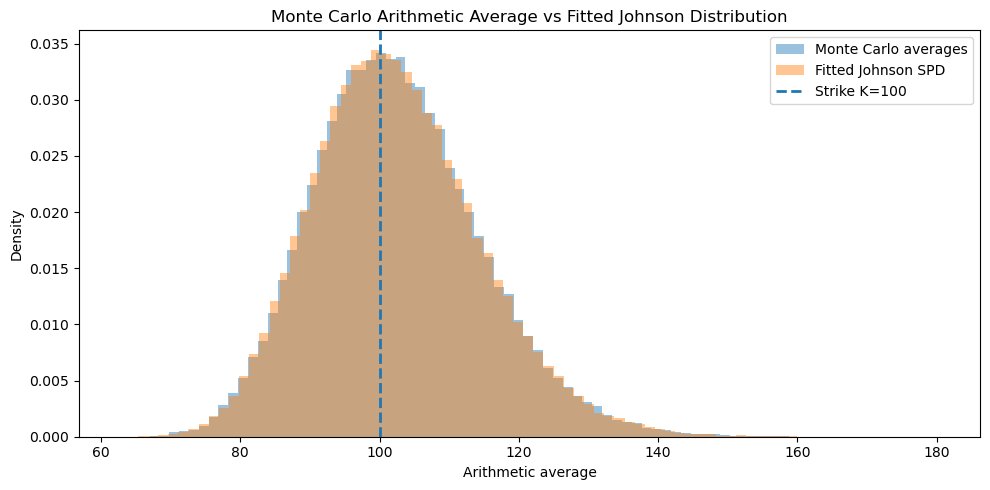

In [92]:
plot_johnson_fit_against_mc(
    S0=S0,
    K=K,
    r=r,
    q=q,
    sigma=sigma,
    T=T,
    n_obs=n_obs,
    params=params,
    n_paths=n_paths,
    seed=seed)